<a href="https://colab.research.google.com/github/samueljohnson-db/RTCleeds/blob/main/road_Incident_weather_ML_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

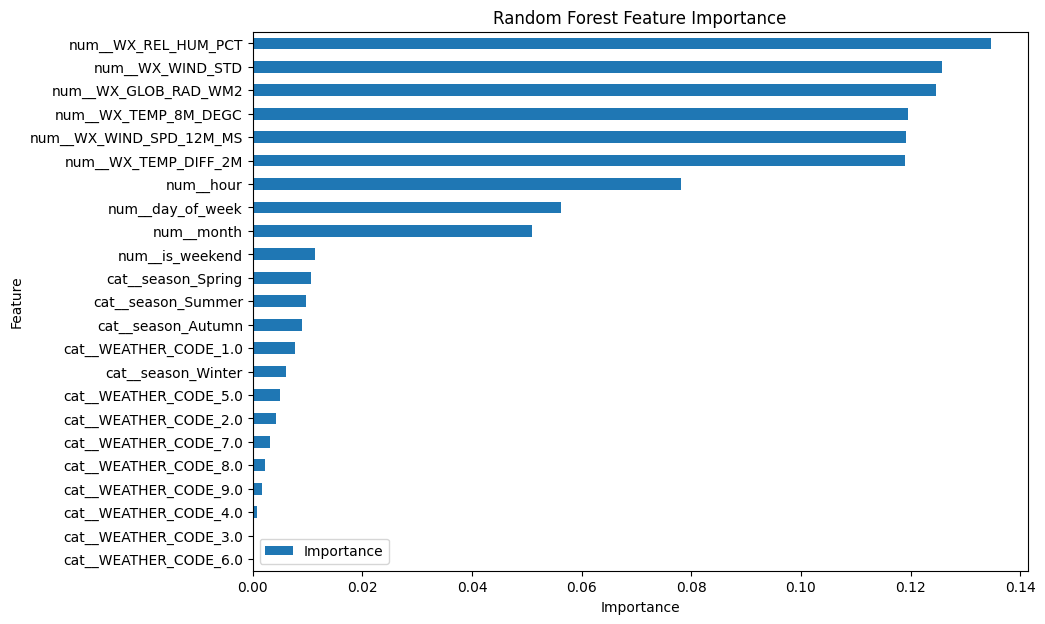

In [104]:
importance.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10, 7)
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

In [103]:
feature_names = rf_B_pipeline.named_steps['preprocessor'].get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_B_pipeline.named_steps['classifier'].feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
9,num__WX_REL_HUM_PCT,0.134616
5,num__WX_WIND_STD,0.125690
8,num__WX_GLOB_RAD_WM2,0.124698
6,num__WX_TEMP_8M_DEGC,0.119459
4,num__WX_WIND_SPD_12M_MS,0.119161
7,num__WX_TEMP_DIFF_2M,0.118985
0,num__hour,0.078195
2,num__day_of_week,0.056234
1,num__month,0.050932
3,num__is_weekend,0.011323


feature importance


In [102]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression A",
        "Logistic Regression B",
        "Random Forest A",
        "Random Forest B"
    ],

    "Balanced Accuracy": [
        balanced_accuracy_score(
            y_test, pred_log_A
        ),
        balanced_accuracy_score(
            y_test, pred_log_B
        ),
        balanced_accuracy_score(
            y_test, pred_rf_A
        ),
        balanced_accuracy_score(
            y_test, pred_rf_B
        )
    ],

    "Macro F1": [
        f1_score(
            y_test, pred_log_A,
            average="macro"
        ),
        f1_score(
            y_test, pred_log_B,
            average="macro"
        ),
        f1_score(
            y_test, pred_rf_A,
            average="macro"
        ),
        f1_score(
            y_test, pred_rf_B,
            average="macro"
        )
    ],

    "Macro Recall": [
        recall_score(
            y_test, pred_log_A,
            average="macro"
        ),
        recall_score(
            y_test, pred_log_B,
            average="macro"
        ),
        recall_score(
            y_test, pred_rf_A,
            average="macro"
        ),
        recall_score(
            y_test, pred_rf_B,
            average="macro"
        )
    ]
})

results

,Model,Balanced Accuracy,Macro F1,Macro Recall
0,Logistic Regression A,0.286945,0.203733,0.286945
1,Logistic Regression B,0.348759,0.243947,0.348759
2,Random Forest A,0.317199,0.314055,0.317199
3,Random Forest B,0.336037,0.316259,0.336037


comparison of model a and b above


In [101]:
print(
    classification_report(
        y_test,
        pred_rf_B
    )
)


              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00        11
         2.0       0.24      0.02      0.03       223
         3.0       0.85      0.99      0.92      1323

    accuracy                           0.84      1557
   macro avg       0.36      0.34      0.32      1557
weighted avg       0.76      0.84      0.78      1557



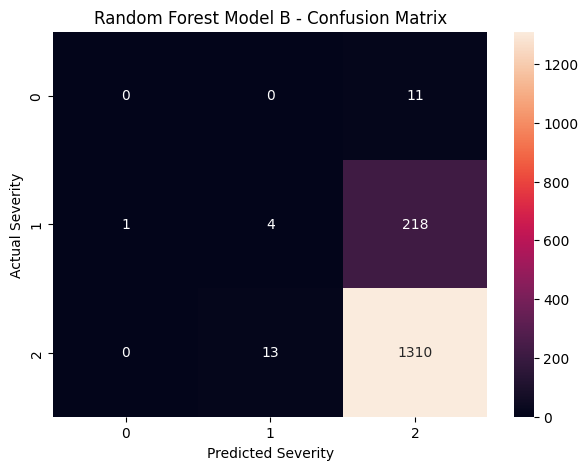

In [100]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted Severity")
plt.ylabel("Actual Severity")
plt.title(
    "Random Forest Model B - Confusion Matrix"
)

plt.show()

In [99]:
cm = confusion_matrix(
    y_test,
    pred_rf_B
)

Final random Forest

In [98]:
evaluate_model(
    "Logistic Regression - Model A",
    y_test,
    pred_log_A
)

evaluate_model(
    "Logistic Regression - Model B",
    y_test,
    pred_log_B
)

evaluate_model(
    "Random Forest - Model A",
    y_test,
    pred_rf_A
)

evaluate_model(
    "Random Forest - Model B",
    y_test,
    pred_rf_B
)

Logistic Regression - Model A
Accuracy: 0.265
Balanced Accuracy: 0.287
Macro F1: 0.204
Macro Precision: 0.343
Macro Recall: 0.287

Classification Report:
              precision    recall  f1-score   support

         1.0       0.00      0.18      0.01        11
         2.0       0.16      0.44      0.23       223
         3.0       0.87      0.24      0.37      1323

    accuracy                           0.26      1557
   macro avg       0.34      0.29      0.20      1557
weighted avg       0.76      0.26      0.35      1557

Logistic Regression - Model B
Accuracy: 0.349
Balanced Accuracy: 0.349
Macro F1: 0.244
Macro Precision: 0.348
Macro Recall: 0.349

Classification Report:
              precision    recall  f1-score   support

         1.0       0.01      0.27      0.01        11
         2.0       0.16      0.44      0.23       223
         3.0       0.88      0.33      0.48      1323

    accuracy                           0.35      1557
   macro avg       0.35      0.35      

In [97]:
def evaluate_model(name, y_true, y_pred):

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        "Accuracy:",
        round(
            accuracy_score(y_true, y_pred),
            3
        )
    )

    print(
        "Balanced Accuracy:",
        round(
            balanced_accuracy_score(y_true, y_pred),
            3
        )
    )

    print(
        "Macro F1:",
        round(
            f1_score(
                y_true,
                y_pred,
                average="macro"
            ),
            3
        )
    )

    print(
        "Macro Precision:",
        round(
            precision_score(
                y_true,
                y_pred,
                average="macro"
            ),
            3
        )
    )

    print(
        "Macro Recall:",
        round(
            recall_score(
                y_true,
                y_pred,
                average="macro"
            ),
            3
        )
    )

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred
        )
    )

Testing all four models

In [94]:
rf_A_pipeline.fit(
    X_train_A,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['hour', 'month',
                                                   'day_of_week',
                                                   'is_weekend']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['season'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [95]:
pred_rf_A = rf_A_pipeline.predict(
    X_test_A
)

In [96]:
print("--- Evaluation for Random Forest Model A ---")
print("Accuracy Score (Random Forest A):", accuracy_score(y_test, pred_rf_A))
print("Balanced Accuracy Score (Random Forest A):", balanced_accuracy_score(y_test, pred_rf_A))
print("\nClassification Report (Random Forest A):\n", classification_report(y_test, pred_rf_A))

--- Evaluation for Random Forest Model A ---
Accuracy Score (Random Forest A): 0.6184971098265896
Balanced Accuracy Score (Random Forest A): 0.31719932616793606

Classification Report (Random Forest A):
               precision    recall  f1-score   support

         1.0       0.00      0.00      0.00        11
         2.0       0.14      0.27      0.18       223
         3.0       0.85      0.68      0.76      1323

    accuracy                           0.62      1557
   macro avg       0.33      0.32      0.31      1557
weighted avg       0.74      0.62      0.67      1557



In [87]:
rf_B_pipeline = Pipeline([
    ('preprocessor', preprocessor_B),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [89]:
rf_B_pipeline.fit(
    X_train_B,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['hour', 'month',
                                                   'day_of_week', 'is_weekend',
                                                   'WX_WIND_SPD_12M_MS',
                                                   'WX_WIND_STD',
                                                   'WX_TEMP_8M_DEGC',
                                                   'WX_TEMP_DIFF_2M',
                                                   'WX_GLOB_RAD_WM2',
                                                   'WX_REL_HUM_PCT']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['season',
                                                   'WEATHER_CODE'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [90]:
pred_rf_B = rf_B_pipeline.predict(
    X_test_B
)

In [91]:
print("\n--- Evaluation for Random Forest Model B ---")
print("Accuracy Score (Random Forest B):", accuracy_score(y_test, pred_rf_B))
print("Balanced Accuracy Score (Random Forest B):", balanced_accuracy_score(y_test, pred_rf_B))
print("\nClassification Report (Random Forest B):\n", classification_report(y_test, pred_rf_B))


--- Evaluation for Random Forest Model B ---
Accuracy Score (Random Forest B): 0.8439306358381503
Balanced Accuracy Score (Random Forest B): 0.33603702234921534

Classification Report (Random Forest B):
               precision    recall  f1-score   support

         1.0       0.00      0.00      0.00        11
         2.0       0.24      0.02      0.03       223
         3.0       0.85      0.99      0.92      1323

    accuracy                           0.84      1557
   macro avg       0.36      0.34      0.32      1557
weighted avg       0.76      0.84      0.78      1557



In [92]:
rf_A_pipeline = Pipeline([
    ('preprocessor', preprocessor_A),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

Random FOREST Model A


In [79]:
logistic_B.fit(
    X_train_B,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['hour', 'month',
                                                   'day_of_week', 'is_weekend',
                                                   'WX_WIND_SPD_12M_MS',
                                                   'WX_WIND_STD',
                                                   'WX_TEMP_8M_DEGC',
                                                   'WX_TEMP_DIFF_2M',
                                                   'WX_GLOB_RAD_WM2',
                                                   'WX_REL_HUM_PCT']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['season',
                                                   'WEATHER_CODE'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [78]:
columns_to_check_for_nan = [
    "CASUALTY_SEVERITY",
    "hour",
    "month",
    "day_of_week",
    "is_weekend",
    "season",
    "WEATHER_CODE",
    "WX_WIND_SPD_12M_MS",
    "WX_WIND_STD",
    "WX_TEMP_8M_DEGC",
    "WX_TEMP_DIFF_2M",
    "WX_GLOB_RAD_WM2",
    "WX_REL_HUM_PCT"
]
incident_df = incident_df.dropna(subset=columns_to_check_for_nan)

In [80]:
pred_log_B = logistic_B.predict(
    X_test_B
)

In [81]:
print("\n--- Evaluation for Logistic Regression Model B ---")
print("Accuracy Score (Model B):", accuracy_score(y_test, pred_log_B))
print("Balanced Accuracy Score (Model B):", balanced_accuracy_score(y_test, pred_log_B))
print("\nClassification Report (Model B):\n", classification_report(y_test, pred_log_B))


--- Evaluation for Logistic Regression Model B ---
Accuracy Score (Model B): 0.348747591522158
Balanced Accuracy Score (Model B): 0.3487594491224642

Classification Report (Model B):
               precision    recall  f1-score   support

         1.0       0.01      0.27      0.01        11
         2.0       0.16      0.44      0.23       223
         3.0       0.88      0.33      0.48      1323

    accuracy                           0.35      1557
   macro avg       0.35      0.35      0.24      1557
weighted avg       0.77      0.35      0.45      1557



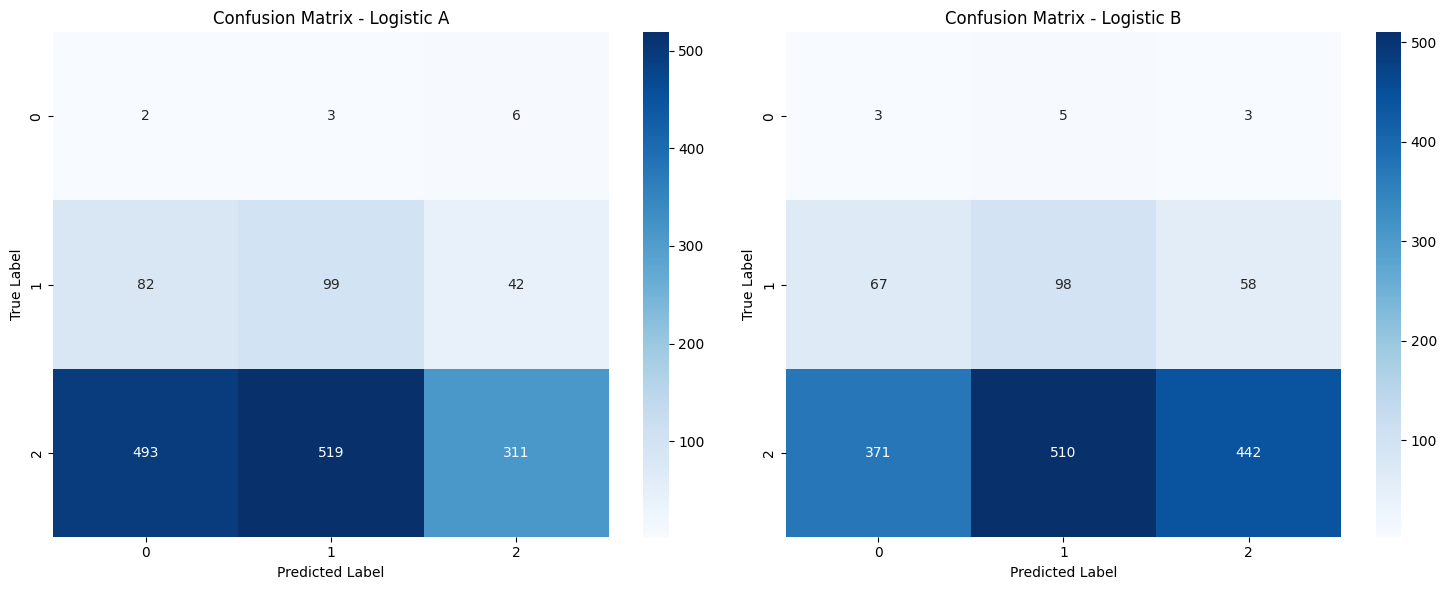

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix for Model A
sns.heatmap(confusion_matrix(y_test, pred_log_A), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Logistic A')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Confusion Matrix for Model B
sns.heatmap(confusion_matrix(y_test, pred_log_B), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix - Logistic B')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

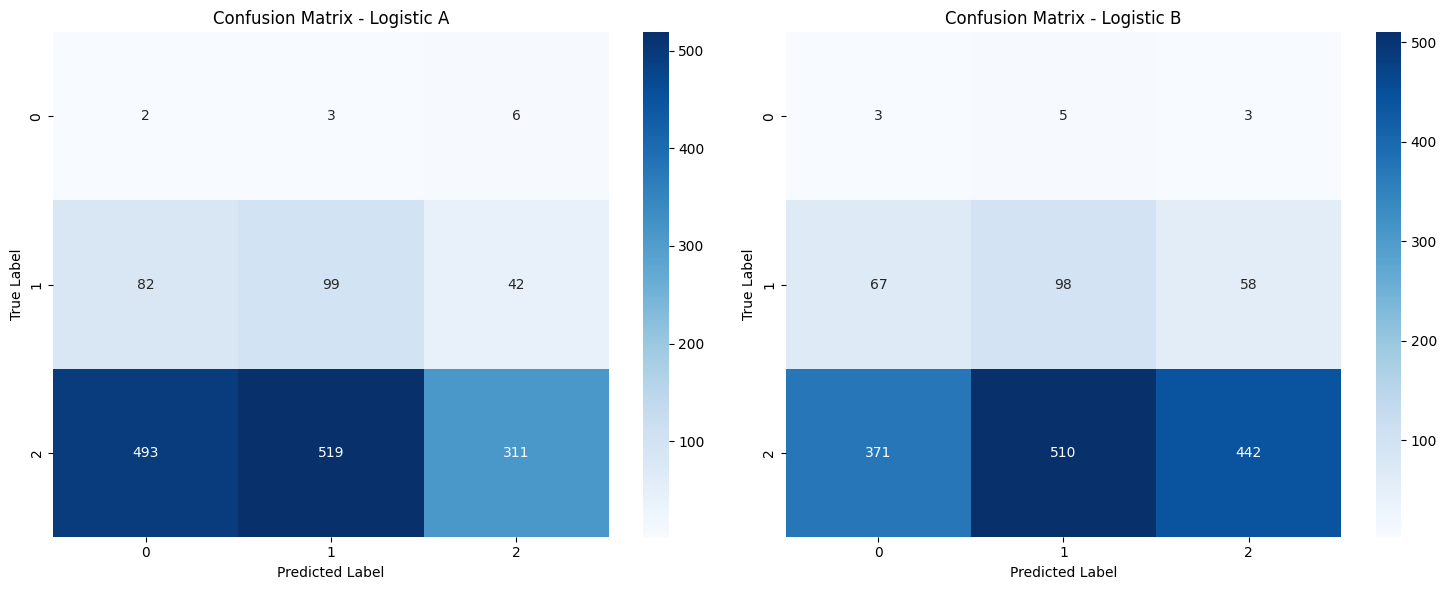

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix for Model A
sns.heatmap(confusion_matrix(y_test, pred_log_A), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Logistic A')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Confusion Matrix for Model B
sns.heatmap(confusion_matrix(y_test, pred_log_B), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix - Logistic B')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [84]:
pred_log_B = logistic_B.predict(
    X_test_B
)

In [70]:
numerical_features_B = [
    'hour',
    'month',
    'day_of_week',
    'is_weekend',
    'WX_WIND_SPD_12M_MS',
    'WX_WIND_STD',
    'WX_TEMP_8M_DEGC',
    'WX_TEMP_DIFF_2M',
    'WX_GLOB_RAD_WM2',
    'WX_REL_HUM_PCT'
]
categorical_features_B = ['season', 'WEATHER_CODE']

preprocessor_B = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_B),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_B)
    ])

logistic_B = Pipeline([
    ('preprocessor', preprocessor_B),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

LOGISTIC REGRESSION FOR MODEL B

In [68]:
pred_log_A = logistic_A.predict(
    X_test_A
)

In [69]:
print("Evaluation for Logistic Regression Model A ")
print("Accuracy Score (Model A):", accuracy_score(y_test, pred_log_A))
print("Balanced Accuracy Score (Model A):", balanced_accuracy_score(y_test, pred_log_A))
print("\nClassification Report (Model A):\n", classification_report(y_test, pred_log_A))

--- Evaluation for Logistic Regression Model A ---
Accuracy Score (Model A): 0.26461143224149003
Balanced Accuracy Score (Model A): 0.286945392219789

Classification Report (Model A):
               precision    recall  f1-score   support

         1.0       0.00      0.18      0.01        11
         2.0       0.16      0.44      0.23       223
         3.0       0.87      0.24      0.37      1323

    accuracy                           0.26      1557
   macro avg       0.34      0.29      0.20      1557
weighted avg       0.76      0.26      0.35      1557



In [66]:
logistic_A.fit(
    X_train_A,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['hour', 'month',
                                                   'day_of_week',
                                                   'is_weekend']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['season'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [65]:
numerical_features = ['hour', 'month', 'day_of_week', 'is_weekend']
categorical_features = ['season']

preprocessor_A = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

logistic_A = Pipeline([
    ('preprocessor', preprocessor_A),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

LOGISTIC REGRESSION ABOVE for MODEL A


In [64]:
X_train_A = X_A.iloc[train_idx]
X_test_A = X_A.iloc[test_idx]

X_train_B = X_B.iloc[train_idx]
X_test_B = X_B.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]
# this ensures that model a and b will be evaluated on exactly the same incidents.

In [63]:
train_idx, test_idx = train_test_split(
    np.arange(len(y)),
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [62]:
X_train_A, X_test_A, y_train, y_test = train_test_split(
    X_A,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [61]:
# This cell is now redundant as comprehensive NaN removal is handled earlier.

In [60]:
# This cell is now redundant as comprehensive NaN removal is handled earlier.

In [59]:
y.value_counts()

,count
CASUALTY_SEVERITY,
3.0,6616
2.0,1115
1.0,53


testing

In [58]:
X_B = incident_df[
    [
        "hour",
        "month",
        "day_of_week",
        "is_weekend",
        "season",
        "WEATHER_CODE",
        "WX_WIND_SPD_12M_MS",
        "WX_WIND_STD",
        "WX_TEMP_8M_DEGC",
        "WX_TEMP_DIFF_2M",
        "WX_GLOB_RAD_WM2",
        "WX_REL_HUM_PCT"
    ]
].copy()

MODEL-B ABOVE

In [57]:
y = incident_df["CASUALTY_SEVERITY"]

In [56]:
X_A = incident_df[
    [
        "hour",
        "month",
        "day_of_week",
        "is_weekend",
        "season"
    ]
].copy()

MODEL-A ABOVE

In [55]:
h_stat, p_value = kruskal(*groups)

print("Kruskal-Wallis H:", h_stat)
print("p-value:", p_value)

Kruskal-Wallis H: 688.2610680063772
p-value: 2.408895092406682e-143


In [54]:
daily_incidents.groupby(
    "weather_condition"
)["incident_count"].describe()

,count,mean,std,min,25%,50%,75%,max
weather_condition,,,,,,,,
Fine with high winds,53.0,1.245283,0.551420,1.0,1.0,1.0,1.0,3.0
Fine without high winds,1995.0,3.509273,2.128587,1.0,2.0,3.0,5.0,13.0
Fog or mist,1.0,1.000000,NaN,1.0,1.0,1.0,1.0,1.0
Other,27.0,1.074074,0.266880,1.0,1.0,1.0,1.0,2.0
Raining with high winds,60.0,1.283333,0.691147,1.0,1.0,1.0,1.0,4.0
Raining without high winds,301.0,1.431894,0.734515,1.0,1.0,1.0,2.0,6.0
Snowing with high winds,4.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
Snowing without high winds,19.0,1.157895,0.374634,1.0,1.0,1.0,1.0,2.0
Unknown,120.0,1.275000,0.579227,1.0,1.0,1.0,1.0,4.0


In [53]:
f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 74.02118375721763
p-value: 4.4798343038762987e-110


In [52]:
groups = [
    group["incident_count"].values
    for _, group
    in daily_incidents.groupby("weather_condition")
]

ANOVA TEST ABOVE

In [51]:
daily_incidents.head()

,date,weather_condition,incident_count
0,2010-01-02,Snowing without high winds,1
1,2010-01-03,Fine without high winds,2
2,2010-01-04,Fine without high winds,2
3,2010-01-06,Fine without high winds,2
4,2010-01-08,Fine without high winds,2


In [50]:
daily_incidents = (
    incident_df
    .groupby(["date", "weather_condition"])
    .size()
    .reset_index(name="incident_count")
)

In [49]:
incident_df["date"] = (
    incident_df["INC_TIMESTAMP"].dt.date
)

above is incident frequncy for each weather condition on a daily incident count

In [48]:
n = contingency_table.to_numpy().sum()

phi2 = chi2 / n

r, k = contingency_table.shape

cramers_v = np.sqrt(
    phi2 / min(k - 1, r - 1)
)

print("Cramér's V:", cramers_v)

Cramér's V: 0.10509564262525345


In [47]:
expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

expected_df

CASUALTY_SEVERITY,1.0,2.0,3.0
weather_condition,,,
Fine with high winds,0.449383,9.454008,56.096608
Fine without high winds,47.668679,1002.841084,5950.490236
Fog or mist,0.006809,0.143243,0.849949
Other,0.197456,4.154034,24.648510
Raining with high winds,0.524281,11.029676,65.446043
Raining without high winds,2.934609,61.737539,366.327852
Snowing with high winds,0.027235,0.572970,3.399794
Snowing without high winds,0.149794,3.151336,18.698869
Unknown,1.041752,21.916110,130.042138


In [46]:
chi2, p, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-square:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)

Chi-square: 171.9500249303518
Degrees of freedom: 16
p-value: 3.43644952191239e-28


In [45]:
contingency_table = pd.crosstab(
    incident_df["weather_condition"],
    incident_df["CASUALTY_SEVERITY"]
)

contingency_table

CASUALTY_SEVERITY,1.0,2.0,3.0
weather_condition,,,
Fine with high winds,1,7,58
Fine without high winds,45,1026,5930
Fog or mist,1,0,0
Other,1,2,26
Raining with high winds,3,11,63
Raining without high winds,2,52,377
Snowing with high winds,0,1,3
Snowing without high winds,0,2,20
Unknown,0,14,139


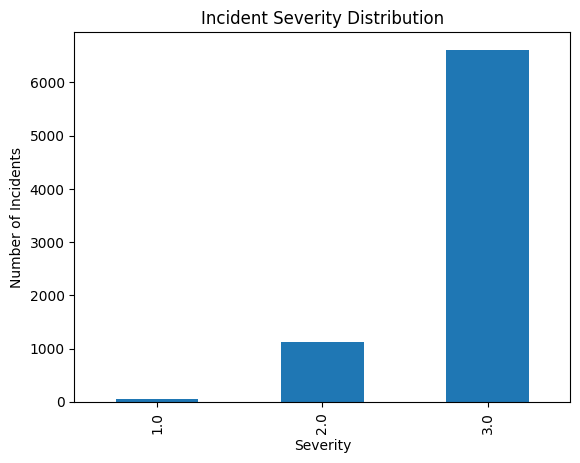

In [44]:
severity_counts.plot(kind="bar")

plt.title("Incident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Incidents")
plt.show()

In [43]:
severity_percentage = (
    incident_df["CASUALTY_SEVERITY"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

severity_percentage

,proportion
CASUALTY_SEVERITY,
3.0,84.99
2.0,14.32
1.0,0.68


In [42]:
severity_counts = (
    incident_df["CASUALTY_SEVERITY"]
    .value_counts()
    .sort_index()
)

severity_counts

,count
CASUALTY_SEVERITY,
1.0,53
2.0,1115
3.0,6616


In [41]:
weather_labels = {

    1: "Fine without high winds",
    2: "Raining without high winds",
    3: "Snowing without high winds",
    4: "Fine with high winds",
    5: "Raining with high winds",
    6: "Snowing with high winds",
    7: "Fog or mist",
    8: "Other",
    9: "Unknown",

}

incident_df["weather_condition"] = (
    incident_df["WEATHER_CODE"]
    .map(weather_labels)
)

In [40]:
columns_to_check_for_nan = [
    "CASUALTY_SEVERITY",
    "hour",
    "month",
    "day_of_week",
    "is_weekend",
    "season",
    "WEATHER_CODE",
    "WX_WIND_SPD_12M_MS",
    "WX_WIND_STD",
    "WX_TEMP_8M_DEGC",
    "WX_TEMP_DIFF_2M",
    "WX_GLOB_RAD_WM2",
    "WX_REL_HUM_PCT"
]
incident_df = incident_df.dropna(subset=columns_to_check_for_nan)

In [39]:
incident_df["WEATHER_CODE"].value_counts().sort_index()

,count
WEATHER_CODE,
1.0,23139
2.0,2520
3.0,162
4.0,339
5.0,320
6.0,26
7.0,37
8.0,282
9.0,370


In [38]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

incident_df["season"] = (
    incident_df["month"].apply(get_season)
)

In [37]:
incident_df["is_weekend"] = (
    incident_df["day_of_week"] >= 5
).astype(int)

In [36]:
incident_df["hour"] = incident_df["INC_TIMESTAMP"].dt.hour

incident_df["month"] = incident_df["INC_TIMESTAMP"].dt.month

incident_df["day_of_week"] = (
    incident_df["INC_TIMESTAMP"].dt.dayofweek
)

In [35]:
incident_df["INC_TIMESTAMP"].max()

Timestamp('2024-12-12 18:13:00')

In [34]:
incident_df["INC_TIMESTAMP"].min()

Timestamp('2009-01-01 00:55:00')

In [33]:
incident_df["INC_TIMESTAMP"] = pd.to_datetime(
    incident_df["INC_TIMESTAMP"],
    dayfirst=True,
    errors="coerce"
)

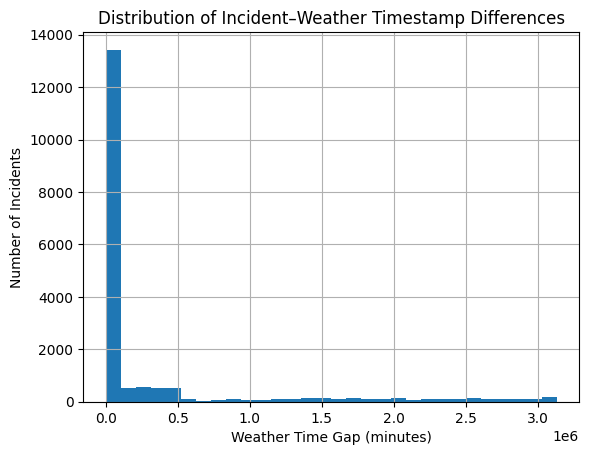

In [32]:
incident_df[
    "WEATHER_TIME_GAP_MINUTES"
].hist(bins=30)

plt.xlabel("Weather Time Gap (minutes)")
plt.ylabel("Number of Incidents")
plt.title("Distribution of Incident–Weather Timestamp Differences")
plt.show()

In [31]:
incident_df["WEATHER_TIME_GAP_MINUTES"].isna().sum()

np.int64(8998)

In [30]:
incident_df["WEATHER_TIME_GAP_MINUTES"].value_counts().sort_index().head(20)

,count
WEATHER_TIME_GAP_MINUTES,
0.0,4231
1.0,574
2.0,589
3.0,605
4.0,531
5.0,5066
6.0,584
7.0,599
195.0,1


In [29]:
incident_df["WEATHER_TIME_GAP_MINUTES"].describe()

,WEATHER_TIME_GAP_MINUTES
count,1.824100e+04
mean,3.189455e+05
std,7.263037e+05
min,0.000000e+00
25%,1.000000e+00
50%,5.000000e+00
75%,1.586400e+05
max,3.128773e+06


In [28]:
incident_df["CASUALTY_SEVERITY"].value_counts()

,count
CASUALTY_SEVERITY,
3.0,22023
2.0,4949
1.0,267


In [27]:
incident_df.head()

,REFERENCE_NUMBER,CASUALTY_SEVERITY,INC_TIMESTAMP,WX_TIMESTAMP,WEATHER_CODE,WX_WIND_DIR_12M,WX_WIND_SPD_12M_MS,WX_WIND_STD,WX_TEMP_8M_DEGC,WX_TEMP_DIFF_2M,WX_GLOB_RAD_WM2,WX_REL_HUM_PCT,WEATHER_TIME_GAP_MINUTES,NUMBER_OF_VEHICLES,ROAD_CLASS,ROAD_SURFACE_CODE,LIGHTING_CODE
0,09G1050,3.0,16/09/2013 15:35,16/09/2013 15:30,9.0,259.6000,8.35999,15.49,12.07,-0.210,196.7000,65.0499,5.0,2.0,1.0,1.0,1.0
1,0A41585,3.0,04/10/2013 19:42,04/10/2013 19:45,1.0,264.4000,5.00200,12.77,15.62,-0.065,NaN,78.3999,3.0,1.0,1.0,1.0,4.0
2,0AB0817,2.0,11/10/2013 14:04,11/10/2013 14:00,8.0,36.2599,5.17999,15.29,12.94,-0.213,91.3999,73.5000,4.0,3.0,1.0,1.0,1.0
3,0AB1477,3.0,11/10/2013 15:30,11/10/2013 15:30,1.0,18.5000,4.63599,18.32,12.45,-0.128,38.9200,73.1000,0.0,2.0,1.0,1.0,1.0
4,0AF0559,3.0,15/10/2013 12:15,15/10/2013 12:15,1.0,19.9400,3.16100,17.10,13.25,-0.374,333.3000,81.1000,0.0,3.0,1.0,1.0,1.0


In [26]:
incident_df.shape

(27239, 17)

In [25]:
incident_df = (
    df.groupby("REFERENCE_NUMBER")
      .agg({
          "CASUALTY_SEVERITY": "min",
          "INC_TIMESTAMP": "first",
          "WX_TIMESTAMP": "first",
          "WEATHER_CODE": "first",
          "WX_WIND_DIR_12M": "first",
          "WX_WIND_SPD_12M_MS": "first",
          "WX_WIND_STD": "first",
          "WX_TEMP_8M_DEGC": "first",
          "WX_TEMP_DIFF_2M": "first",
          "WX_GLOB_RAD_WM2": "first",
          "WX_REL_HUM_PCT": "first",
          "WEATHER_TIME_GAP_MINUTES": "first",
          "NUMBER_OF_VEHICLES": "first",
          "ROAD_CLASS": "first",
          "ROAD_SURFACE_CODE": "first",
          "LIGHTING_CODE": "first"
      })
      .reset_index()
)

In [24]:
df["REFERENCE_NUMBER"].value_counts().head(20)

,count
REFERENCE_NUMBER,
69T0667,26
58K1318,18
1530194,18
6360200,18
1375943,16
1231145,16
1182601,16
1448325,16
58F1730,14


In [23]:
len(df)

54165

In [22]:
df["REFERENCE_NUMBER"].nunique()

27239

In [21]:
df.columns.tolist()

['ID',
 'REFERENCE_NUMBER',
 'NUMBER_OF_VEHICLES',
 'FULL_DATE',
 'FULL_TIME',
 'ROAD_CLASS',
 'ROAD_SURFACE_CODE',
 'LIGHTING_CODE',
 'WEATHER_CODE',
 'CASUALTY_CLASS',
 'SEX_OF_CASUALTY',
 'AGE_OF_CASUALTY',
 'CASUALTY_SEVERITY',
 'VEHICLE_1',
 'INC_TIMESTAMP',
 'WX_TIMESTAMP',
 'WX_WIND_DIR_12M',
 'WX_WIND_SPD_12M_MS',
 'WX_WIND_STD',
 'WX_TEMP_8M_DEGC',
 'WX_TEMP_DIFF_2M',
 'WX_GLOB_RAD_WM2',
 'WX_REL_HUM_PCT',
 'WEATHER_TIME_GAP_MINUTES']

In [20]:
df.shape

(54165, 24)

In [19]:
df.head()

,ID,REFERENCE_NUMBER,NUMBER_OF_VEHICLES,FULL_DATE,FULL_TIME,ROAD_CLASS,ROAD_SURFACE_CODE,LIGHTING_CODE,WEATHER_CODE,CASUALTY_CLASS,...,INC_TIMESTAMP,WX_TIMESTAMP,WX_WIND_DIR_12M,WX_WIND_SPD_12M_MS,WX_WIND_STD,WX_TEMP_8M_DEGC,WX_TEMP_DIFF_2M,WX_GLOB_RAD_WM2,WX_REL_HUM_PCT,WEATHER_TIME_GAP_MINUTES
0,211,3360593,2.0,03/06/2016,11:15,6.0,1.0,1.0,1.0,2.0,...,06/03/2016 11:15,06/03/2016 11:15,276.8,2.296,16.25,3.660,-0.242,162.60,70.7999,0.0
1,212,3360648,2.0,03/06/2016,11:55,6.0,1.0,1.0,9.0,1.0,...,06/03/2016 11:55,06/03/2016 12:00,280.3,2.219,18.35,4.700,-0.135,450.90,60.2900,5.0
2,213,3360648,2.0,03/06/2016,11:55,6.0,1.0,1.0,9.0,2.0,...,06/03/2016 11:55,06/03/2016 12:00,280.3,2.219,18.35,4.700,-0.135,450.90,60.2900,5.0
3,214,3361088,3.0,03/06/2016,16:45,3.0,1.0,1.0,1.0,2.0,...,06/03/2016 16:45,06/03/2016 16:45,301.2,2.985,20.67,4.478,-0.185,59.79,52.0000,0.0
4,215,3361088,3.0,03/06/2016,16:45,3.0,1.0,1.0,1.0,1.0,...,06/03/2016 16:45,06/03/2016 16:45,301.2,2.985,20.67,4.478,-0.185,59.79,52.0000,0.0


In [18]:
df = pd.read_csv(
    "/content/finished master document weather and incidents.csv"
)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from scipy.stats import kruskal

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score
)

from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")